In [2]:
# ╔══════════════════════════════════════════════════════════╗
# ║          VAE Notebook — Anomaly Detection                ║
# ╚══════════════════════════════════════════════════════════╝

!pip install -q torch torchvision matplotlib scikit-learn tqdm

import os, random, numpy as np
import torch, torch.nn as nn, torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)



Device: cuda


In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
TRAIN_ROOT = "/kaggle/input/datasets/yatishrajan/lggdata/LGG/train"
TEST_ROOT  = "/kaggle/input/datasets/yatishrajan/lggdata/LGG/test"

# ── Dataset Class ─────────────────────────────────────────────────────────────   
class LGGDataset(Dataset):
    def __init__(self, full_path, transform=None):
        self.transform = transform
        self.samples = []
        
        if os.path.exists(full_path):
            self.samples = [
                os.path.join(full_path, f) 
                for f in sorted(os.listdir(full_path)) 
                if f.lower().endswith(".tif")
            ]
        else:
            print(f" Error: Path not found: {full_path}")

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img_path = self.samples[idx]
        img = Image.open(img_path).convert("L")
        if self.transform: img = self.transform(img)
        return img, img_path

# --- INITIALIZATION ---
IMG_SIZE = 256
BATCH_SIZE = 32
LR         = 1e-3
LATENT_DIM = 128
EPOCHS_VAE = 50

transform = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor()])

# POINT TO THE SPECIFIC FOLDERS REVEALED IN YOUR SCREENSHOT
normal_ds   = LGGDataset(os.path.join(TRAIN_ROOT, "NORMAL"), transform=transform)
abnormal_ds = LGGDataset(os.path.join(TEST_ROOT,  "ABNORMAL"), transform=transform)


print(f"Normal slices (from train): {len(normal_ds)}")
print(f"Abnormal slices (from test): {len(abnormal_ds)}")

# --- DATALOADERS ---
if len(normal_ds) > 0 and len(abnormal_ds) > 0:
    normal_loader   = DataLoader(normal_ds,   batch_size=BATCH_SIZE, shuffle=True)
    abnormal_loader = DataLoader(abnormal_ds, batch_size=BATCH_SIZE, shuffle=False)
else:
    # Final debug check if test path is also slightly different
    if not os.path.exists(TEST_ROOT):
        print(f" TEST_ROOT not found. Check if 'test' is inside 'train' or elsewhere.")
    elif "ABNORMAL" not in os.listdir(TEST_ROOT):
        print(f" ABNORMAL not found in test. Available folders: {os.listdir(TEST_ROOT)}")

Normal slices (from train): 2044
Abnormal slices (from test): 1373


In [ ]:
# ── VAE Model Definition ─────────────────────────────────────────────────────
class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        # ── encoder ──────────────────────────────────────────────
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(),    # 256 -> 128
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),   # 128 -> 64
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),  # 64 -> 32
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU(), # 32 -> 16
            nn.Flatten()
        )
        
        # 256 * 16 * 16 = 65536
        self.fc_mu  = nn.Linear(256*16*16, latent_dim)
        self.fc_var = nn.Linear(256*16*16, latent_dim)
        
        # ── decoder ──────────────────────────────────────────────
        self.fc_dec = nn.Linear(latent_dim, 256*16*16)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(), # 16 -> 32
            nn.ConvTranspose2d(128, 64,  4, 2, 1), nn.ReLU(), # 32 -> 64
            nn.ConvTranspose2d(64,  32,  4, 2, 1), nn.ReLU(), # 64 -> 128
            nn.ConvTranspose2d(32,   1,  4, 2, 1), nn.Sigmoid() # 128 -> 256
        )

    def reparameterise(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        h     = self.encoder(x)
        mu    = self.fc_mu(h)
        lv    = self.fc_var(h)
        z     = self.reparameterise(mu, lv)
        # Change view from (8, 8) to (16, 16)
        xh    = self.decoder(self.fc_dec(z).view(-1, 256, 16, 16))
        return xh, mu, lv

vae = VAE(LATENT_DIM).to(DEVICE)
print("VAE params:", sum(p.numel() for p in vae.parameters()))

VAE params: 26609601


In [ ]:
# ── VAE Loss ──────────────────────────────────────────────────────────────────
def vae_loss(recon_x, x, mu, log_var, beta=1.0):
    # Reconstruction loss (pixel-wise BCE)
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction="sum")
    # KL divergence: -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    kl_loss    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


In [9]:
# ── Training ──────────────────────────────────────────────────────────────────
optimizer = optim.Adam(vae.parameters(), lr=LR)

history = {"total": [], "recon": [], "kl": []}

for epoch in range(1, EPOCHS_VAE + 1):
    vae.train()
    tot_loss = recon_loss_ep = kl_loss_ep = 0.0
    for imgs, _ in tqdm(normal_loader, desc=f"Epoch {epoch}/{EPOCHS_VAE}", leave=False):
        imgs = imgs.to(DEVICE)
        optimizer.zero_grad()
        recon, mu, lv = vae(imgs)
        loss, rl, kl  = vae_loss(recon, imgs, mu, lv)
        loss.backward()
        optimizer.step()
        tot_loss    += loss.item()
        recon_loss_ep += rl.item()
        kl_loss_ep    += kl.item()

    n = len(normal_loader.dataset)
    history["total"].append(tot_loss / n)
    history["recon"].append(recon_loss_ep / n)
    history["kl"].append(kl_loss_ep / n)
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Total: {tot_loss/n:.2f}  Recon: {recon_loss_ep/n:.2f}  KL: {kl_loss_ep/n:.2f}")


torch.save(vae.state_dict(), "/kaggle/working/vae_weights.pth")
print(" Saved vae_weights.pth")


Epoch 10 | Total: 14304.91  Recon: 14188.54  KL: 116.37


Epoch 20 | Total: 14000.07  Recon: 13881.89  KL: 118.18


Epoch 30 | Total: 13874.59  Recon: 13757.40  KL: 117.20


Epoch 40 | Total: 13803.23  Recon: 13687.45  KL: 115.78


Epoch 50 | Total: 13770.82  Recon: 13657.67  KL: 113.15
 Saved vae_weights.pth


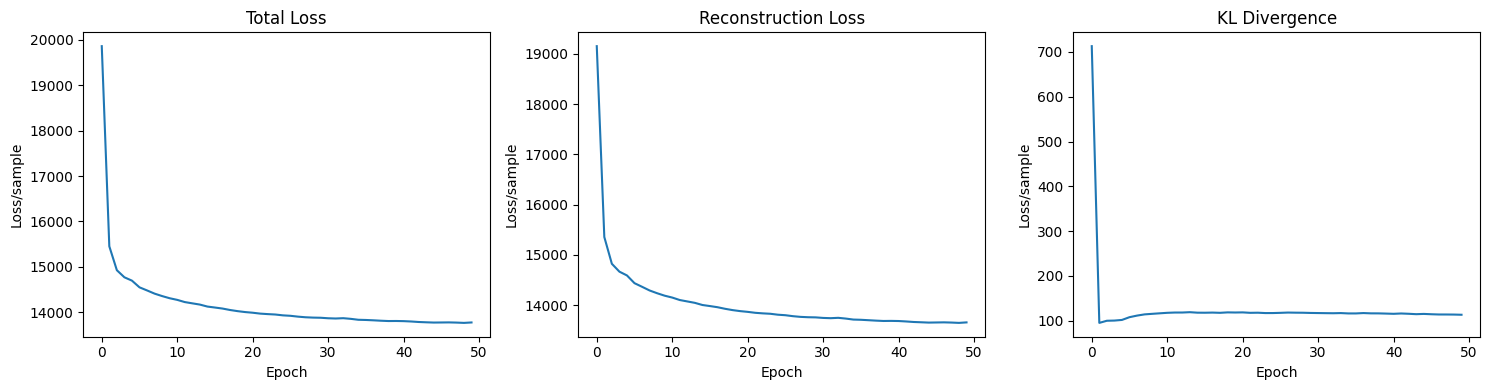

 Saved vae_training_curves.png


In [11]:
# ── VAE Training Curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
names = ["total", "recon", "kl"]
titles = ["Total Loss", "Reconstruction Loss", "KL Divergence"]
for ax, k, t in zip(axes, names, titles):
    ax.plot(history[k])
    ax.set_title(t); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss/sample")
plt.tight_layout()
plt.savefig("/kaggle/working/vae_training_curves.png", dpi=150)
plt.show()
print(" Saved vae_training_curves.png")


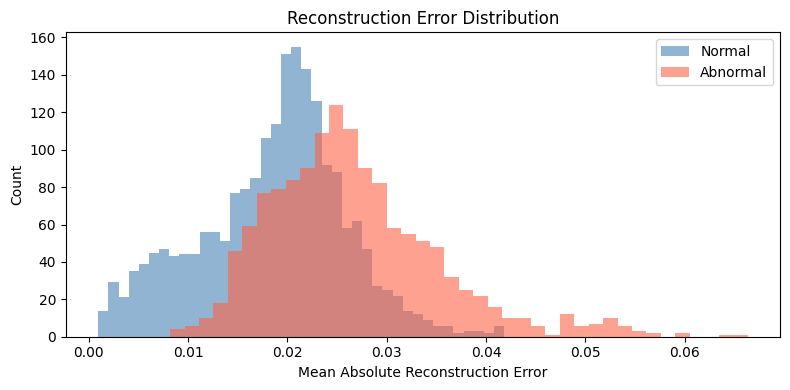

✅ Saved recon_error_plot.png


In [12]:
# ── Validation — Reconstruction Error Distribution ───────────────────────────
normal_errors, abnormal_errors = [], []

vae.eval()
with torch.no_grad():
    for imgs, _ in normal_loader:
        r, _, _ = vae(imgs.to(DEVICE))
        normal_errors.extend(torch.abs(imgs.to(DEVICE) - r).mean(dim=[1,2,3]).cpu().tolist())
    for imgs, _ in abnormal_loader:
        r, _, _ = vae(imgs.to(DEVICE))
        abnormal_errors.extend(torch.abs(imgs.to(DEVICE) - r).mean(dim=[1,2,3]).cpu().tolist())

plt.figure(figsize=(8, 4))
plt.hist(normal_errors,   bins=40, alpha=0.6, label="Normal",   color="steelblue")
plt.hist(abnormal_errors, bins=40, alpha=0.6, label="Abnormal", color="tomato")
plt.xlabel("Mean Absolute Reconstruction Error"); plt.ylabel("Count")
plt.title("Reconstruction Error Distribution"); plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/recon_error_plot.png", dpi=150)
plt.show()
print("✅ Saved recon_error_plot.png")


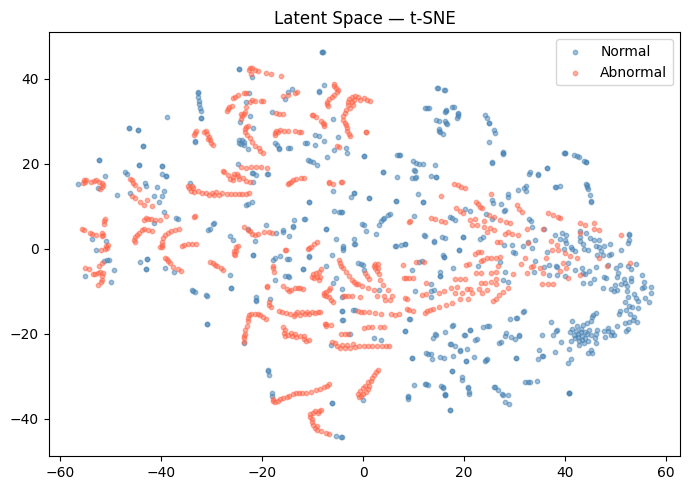

Saved latent_tsne.png


In [13]:
# ── Validation — Latent Space t-SNE ──────────────────────────────────────────
def get_latents(loader, n_batches=20):
    zs = []
    vae.eval()
    with torch.no_grad():
        for b, (imgs, _) in enumerate(loader):
            if b >= n_batches: break
            h  = vae.encoder(imgs.to(DEVICE))
            mu = vae.fc_mu(h)
            zs.append(mu.cpu().numpy())
    return np.concatenate(zs)

z_normal   = get_latents(normal_loader)
z_abnormal = get_latents(abnormal_loader)
z_all      = np.concatenate([z_normal, z_abnormal])
labels     = np.array([0]*len(z_normal) + [1]*len(z_abnormal))

tsne  = TSNE(n_components=2, random_state=SEED, perplexity=30)
z_2d  = tsne.fit_transform(z_all)

plt.figure(figsize=(7, 5))
plt.scatter(z_2d[labels==0, 0], z_2d[labels==0, 1], s=10, alpha=0.5, label="Normal",   c="steelblue")
plt.scatter(z_2d[labels==1, 0], z_2d[labels==1, 1], s=10, alpha=0.5, label="Abnormal", c="tomato")
plt.title("Latent Space — t-SNE"); plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/latent_tsne.png", dpi=150)
plt.show()
print("Saved latent_tsne.png")


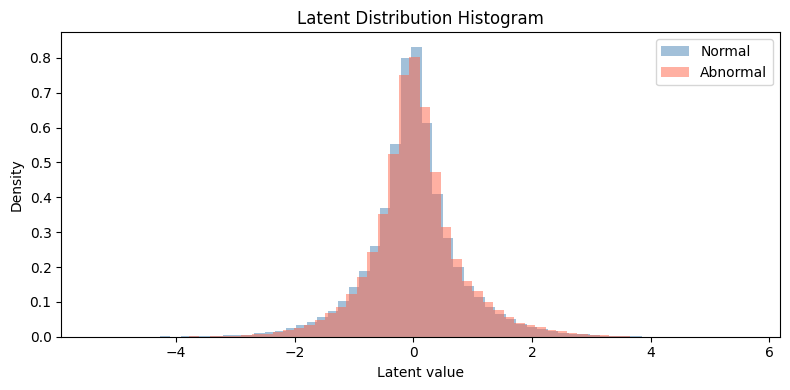

 Saved latent_histogram.png


In [14]:
# ── Validation — Latent Distribution Histogram ───────────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(z_normal.flatten(),   bins=60, alpha=0.5, label="Normal",   density=True, color="steelblue")
plt.hist(z_abnormal.flatten(), bins=60, alpha=0.5, label="Abnormal", density=True, color="tomato")
plt.xlabel("Latent value"); plt.ylabel("Density")
plt.title("Latent Distribution Histogram"); plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/latent_histogram.png", dpi=150)
plt.show()
print(" Saved latent_histogram.png")


In [15]:
# ── Full Dataset Reconstruction + Error Maps ──────────────────────────────────
vae.eval()

def get_recon_and_error(loader, n_batches=4):
    originals, recons, errors, paths = [], [], [], []
    with torch.no_grad():
        for b, (imgs, fnames) in enumerate(loader):
            if b >= n_batches: break
            imgs = imgs.to(DEVICE)
            r, _, _ = vae(imgs)
            err = torch.abs(imgs - r)
            originals.append(imgs.cpu())
            recons.append(r.cpu())
            errors.append(err.cpu())
            paths.extend(fnames)
    return (torch.cat(originals), torch.cat(recons),
            torch.cat(errors),    paths)

orig, recon, err, fpaths = get_recon_and_error(abnormal_loader)
print("Shapes →  orig:", orig.shape, "  recon:", recon.shape, "  error:", err.shape)


Shapes →  orig: torch.Size([128, 1, 256, 256])   recon: torch.Size([128, 1, 256, 256])   error: torch.Size([128, 1, 256, 256])


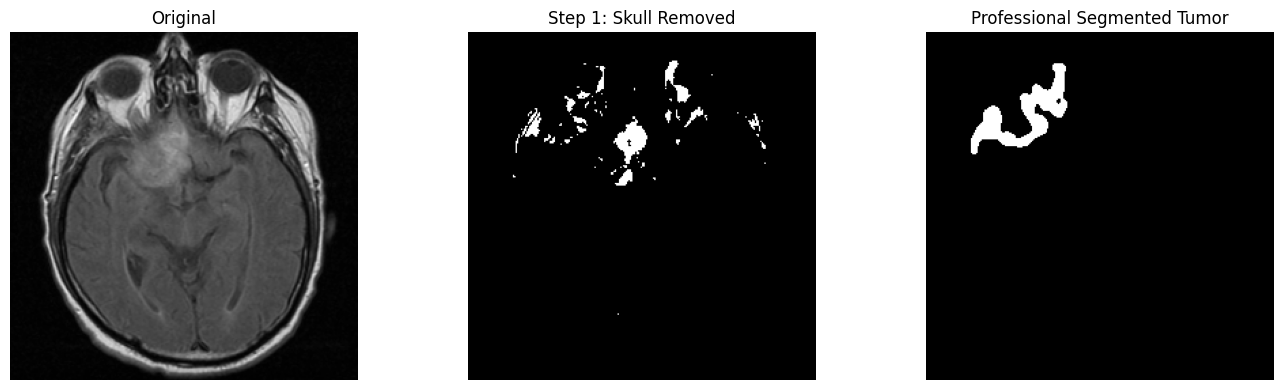

✅ Saved professional_segmented_tumor.png


In [19]:
# ── Evaluation — ROI Subtraction + Professional Segmented Tumor (sample) ─────
res_img      = err[0].cpu().squeeze().numpy()
orig_img     = orig[0].cpu().squeeze().numpy()

binary_tumor = (res_img > 0.14).astype(np.uint8)
brain_mask   = (orig_img > 0.1).astype(np.uint8)
brain_mask   = cv2.erode(brain_mask, np.ones((7,7),np.uint8), iterations=2)
clean_step1  = binary_tumor * brain_mask
dilated      = cv2.dilate(clean_step1, np.ones((5,5),np.uint8), iterations=1)
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(dilated)
final_mask   = np.zeros_like(dilated)
if num_labels > 1:
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    final_mask[labels == largest] = 1

final_mask_smooth = cv2.GaussianBlur(final_mask.astype(float),(11,11),0)
final_mask_smooth = (final_mask_smooth > 0.5).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(orig_img,         cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(clean_step1,      cmap="gray"); axes[1].set_title("Step 1: Skull Removed"); axes[1].axis("off")
axes[2].imshow(final_mask_smooth,cmap="gray"); axes[2].set_title("Professional Segmented Tumor"); axes[2].axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/professional_segmented_tumor.png", dpi=150)
plt.show()
print("✅ Saved professional_segmented_tumor.png")

In [21]:
from matplotlib import cm
# ── Evaluation — Save ALL Abnormal Images (VAE Recon / ROI / Tumor / Heatmap) ─
VAE_RECON_DIR  = "/kaggle/working/vae_reconstructions"
ROI_DIR        = "/kaggle/working/roi_subtractions"
SEG_TUMOR_DIR  = "/kaggle/working/segmented_tumors"
HEATMAP_OV_DIR = "/kaggle/working/heatmap_overlays"
for d in [VAE_RECON_DIR, ROI_DIR, SEG_TUMOR_DIR, HEATMAP_OV_DIR]:
    os.makedirs(d, exist_ok=True)

for orig_t, recon_t, err_t, fpath in zip(orig, recon, err, fpaths):
    stem     = os.path.splitext(os.path.basename(fpath))[0]
    orig_np  = orig_t.squeeze().numpy()
    recon_np = recon_t.squeeze().numpy()
    err_np   = err_t.squeeze().numpy()

    # 1. VAE reconstruction
    fig, ax = plt.subplots(1,2,figsize=(8,4))
    ax[0].imshow(orig_np,  cmap="gray"); ax[0].set_title("Original"); ax[0].axis("off")
    ax[1].imshow(recon_np, cmap="gray"); ax[1].set_title("VAE Recon"); ax[1].axis("off")
    plt.suptitle(stem); plt.tight_layout()
    plt.savefig(os.path.join(VAE_RECON_DIR, f"{stem}_vae_recon.png"), dpi=100, bbox_inches="tight")
    plt.close()

    # 2. ROI subtraction
    fig, ax = plt.subplots(1,3,figsize=(12,4))
    ax[0].imshow(orig_np,  cmap="gray"); ax[0].set_title("Input");   ax[0].axis("off")
    ax[1].imshow(recon_np, cmap="gray"); ax[1].set_title("Recon");   ax[1].axis("off")
    ax[2].imshow(err_np,   cmap="hot");  ax[2].set_title("ROI Sub"); ax[2].axis("off")
    plt.suptitle(stem); plt.tight_layout()
    plt.savefig(os.path.join(ROI_DIR, f"{stem}_roi.png"), dpi=100, bbox_inches="tight")
    plt.close()

    # 3. Professional segmented tumor
    bt   = (err_np > 0.14).astype(np.uint8)
    bm   = cv2.erode((orig_np>0.1).astype(np.uint8), np.ones((7,7),np.uint8), iterations=2)
    dil  = cv2.dilate(bt*bm, np.ones((5,5),np.uint8), iterations=1)
    nl, lb, st, _ = cv2.connectedComponentsWithStats(dil)
    fm   = np.zeros_like(dil)
    if nl > 1: fm[lb == (1+np.argmax(st[1:,cv2.CC_STAT_AREA]))] = 1
    sm   = (cv2.GaussianBlur(fm.astype(float),(11,11),0) > 0.5).astype(np.uint8)
    fig, ax = plt.subplots(1,2,figsize=(8,4))
    ax[0].imshow(orig_np, cmap="gray"); ax[0].set_title("Original"); ax[0].axis("off")
    ax[1].imshow(sm,      cmap="gray"); ax[1].set_title("Segmented Tumor"); ax[1].axis("off")
    plt.suptitle(stem); plt.tight_layout()
    plt.savefig(os.path.join(SEG_TUMOR_DIR, f"{stem}_tumor.png"), dpi=100, bbox_inches="tight")
    plt.close()

    # 4. Heatmap overlay
    heat_rgb = cm.jet(err_np/(err_np.max()+1e-8))[:,:,:3]
    overlay  = np.clip(0.6*np.stack([orig_np]*3,-1)+0.4*heat_rgb, 0, 1)
    fig, ax  = plt.subplots(1,2,figsize=(8,4))
    ax[0].imshow(orig_np, cmap="gray"); ax[0].set_title("Original");      ax[0].axis("off")
    ax[1].imshow(overlay);              ax[1].set_title("Heatmap Overlay"); ax[1].axis("off")
    plt.suptitle(stem); plt.tight_layout()
    plt.savefig(os.path.join(HEATMAP_OV_DIR, f"{stem}_heatmap.png"), dpi=100, bbox_inches="tight")
    plt.close()

print(f"✅ {len(fpaths)} images saved across 4 output folders")


✅ 128 images saved across 4 output folders


In [22]:
import os
HEATMAP_DIR = "/kaggle/working/heatmaps"
os.makedirs(HEATMAP_DIR, exist_ok=True)

vae.eval()
with torch.no_grad():
    for imgs, fnames in tqdm(abnormal_loader, desc="Saving heatmaps"):
        imgs_dev = imgs.to(DEVICE)
        r, _, _  = vae(imgs_dev)
        errors   = torch.abs(imgs_dev - r).cpu()
        for heat, fpath in zip(errors, fnames):
            fname = os.path.basename(fpath).replace(".tif", "_heatmap.npy")
            np.save(os.path.join(HEATMAP_DIR, fname), heat.squeeze().numpy())

print(f"Heatmaps saved to {HEATMAP_DIR}")

Saving heatmaps: 100%|██████████| 43/43 [00:09<00:00,  4.53it/s]

Heatmaps saved to /kaggle/working/heatmaps


In [23]:
# ── ROI Quality Analysis ──────────────────────────────────────────────────────
from scipy.ndimage import sobel
from scipy.ndimage import uniform_filter

def analyse_roi(error_map):
    """error_map: numpy HxW in [0,1]"""
    # Smoothness: inverse of std of Laplacian
    lap  = error_map - uniform_filter(error_map, size=5)
    smoothness = 1.0 / (lap.std() + 1e-8)
    # Edge pixel count via Sobel
    sx   = sobel(error_map, axis=0); sy = sobel(error_map, axis=1)
    mag  = np.hypot(sx, sy)
    edge_count = int((mag > mag.mean() + mag.std()).sum())
    # Noise ratio: high-freq energy / total energy
    noise_ratio = lap.var() / (error_map.var() + 1e-8)
    return {"smoothness": round(smoothness, 3),
            "edge_pixel_count": edge_count,
            "noise_ratio": round(noise_ratio, 4)}

print("ROI Analysis (VAE error maps)\n" + "="*40)
for i in range(3):
    em = err[i].squeeze().numpy()
    stats = analyse_roi(em)
    print(f"Sample {i+1}: {stats}")


ROI Analysis (VAE error maps)
Sample 1: {'smoothness': np.float32(37.194), 'edge_pixel_count': 8408, 'noise_ratio': np.float32(0.2116)}
Sample 2: {'smoothness': np.float32(38.982), 'edge_pixel_count': 8230, 'noise_ratio': np.float32(0.1694)}
Sample 3: {'smoothness': np.float32(39.494), 'edge_pixel_count': 8017, 'noise_ratio': np.float32(0.157)}


In [24]:
# ── Download All VAE Outputs ──────────────────────────────────────────────────
import zipfile
from IPython.display import FileLink, display

VAE_ZIP = "/kaggle/working/vae_all_outputs.zip"
DIRS = {
    "vae_reconstructions": "/kaggle/working/vae_reconstructions",
    "roi_subtractions":    "/kaggle/working/roi_subtractions",
    "segmented_tumors":    "/kaggle/working/segmented_tumors",
    "heatmap_overlays":    "/kaggle/working/heatmap_overlays",
    "heatmaps_npy":        "/kaggle/working/heatmaps",
}
PLOTS = [
    "/kaggle/working/vae_training_curves.png",
    "/kaggle/working/recon_error_plot.png",
    "/kaggle/working/latent_tsne.png",
    "/kaggle/working/latent_histogram.png",
    "/kaggle/working/professional_segmented_tumor.png",
]

with zipfile.ZipFile(VAE_ZIP, "w", zipfile.ZIP_DEFLATED) as zf:
    for folder_name, folder_path in DIRS.items():
        if not os.path.exists(folder_path):
            print(f"⚠️  Skipping: {folder_path}"); continue
        for root, _, files in os.walk(folder_path):
            for f in files:
                abs_p = os.path.join(root, f)
                zf.write(abs_p, os.path.join(folder_name, os.path.relpath(abs_p, folder_path)))
        print(f"✅ Packed: {folder_name}/")
    for fp in PLOTS:
        if os.path.exists(fp):
            zf.write(fp, os.path.join("plots", os.path.basename(fp)))
            print(f"✅ Packed plot: {os.path.basename(fp)}")

print(f"\n📦 ZIP size: {os.path.getsize(VAE_ZIP)/1024/1024:.1f} MB")
display(FileLink(VAE_ZIP, result_html_prefix="⬇️  Download VAE outputs: "))


✅ Packed: vae_reconstructions/
✅ Packed: roi_subtractions/
✅ Packed: segmented_tumors/
✅ Packed: heatmap_overlays/
✅ Packed: heatmaps_npy/
✅ Packed plot: vae_training_curves.png
✅ Packed plot: recon_error_plot.png
✅ Packed plot: latent_tsne.png
✅ Packed plot: latent_histogram.png
✅ Packed plot: professional_segmented_tumor.png

📦 ZIP size: 391.7 MB


/kaggle/working/vae_all_outputs.zip